# Time dependent optimization (PyTorch version)
In this example, we use the inverse computing capibilities of NeuralMag in order to optimize the direction of an external field in order to control the magnetization dynamics of a single-domain particle. Specifilly, the field is optimized such that the magnetization is pointing in a given direction $\vec{m}_\text{target}$ at time $T$. This example is taken from [1] and reads

$$
\begin{align}
    \vec{H}_\text{ext}(\theta, \phi) &= H_c \begin{pmatrix}
    \sin(\theta) \cos(\phi)\\
    \sin(\theta) \sin(\phi)\\
    \cos(\theta)
    \end{pmatrix},\\
    \vec{H}_\text{eff} &= \vec{H}_\text{aniso} + \vec{H}_\text{exchange} + \vec{H}_\text{ext},\\
    \mathcal{L}(\theta, \phi) &= \int_{\Omega} \|\vec{m}(T) - \vec{m}_\text{target}\| \,\text{d}V.
\end{align}
$$

## Simulation
For this example, we use the JAX backend together with the [Optax](https://optax.readthedocs.io/en/latest/) library for optimiz
### Import libraries
Import libraries, set backend to JAX and reduce FEM quadrature order for better performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import constants
from tqdm import tqdm

import neuralmag as nm

nm.config.backend = "torch"
nm.config.fem["n_gauss"] = 1

2025-05-13 13:49:14 NeuralMag:INFO [NeuralMag] Version 0.9.1
2025-05-13 13:49:14 NeuralMag:INFO [NeuralMag] Backend set to 'torch'.


### Setup mesh and state
Setup mesh, state and material parameters and set initial magnetization in z-direction.

In [2]:
mesh = nm.Mesh((2, 2, 2), (5e-9, 5e-9, 5e-9))
state = nm.State(mesh)

state.material.Ms = 8e5
state.material.A = 1.3e-11
state.material.Ku = 1e5
state.material.Ku_axis = [0, 0, 1]
state.material.alpha = 0.1

state.m = nm.VectorFunction(state).fill((0, 0, 1))

2025-05-13 13:49:14 NeuralMag:INFO [Mesh] 3D, 2 x 2 x 2 (size = 5e-09 x 5e-09 x 5e-09)
2025-05-13 13:49:14 NeuralMag:INFO [NeuralMag] Set default device to 'cpu'.
2025-05-13 13:49:14 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-05-13 13:49:14 NeuralMag:INFO [State] Running on device: cpu (dtype = torch.float32, backend = torch)


### Set up external-field function
Next, we set up the external-field function as dynamic attribute depending and the spherical angles $\phi$ and $\theta$.

In [3]:
H = 2 * 1e5 / (constants.mu_0 * 8e5)
state.phi = lambda angles: angles[0]
state.theta = lambda angles: angles[1]
state.angles = [torch.pi / 2, torch.pi / 2]
h_ext = lambda angles: torch.stack(
    [
        H / 2 * torch.sin(angles[0]) * torch.cos(angles[1]),
        H / 2 * torch.sin(angles[0]) * torch.sin(angles[1]),
        H / 2 * torch.cos(angles[0]),
    ]
)

### Set up effective field

In [4]:
nm.ExchangeField().register(state, "exchange")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.ExternalField(h_ext).register(state, "external")
nm.TotalField("exchange", "aniso", "external").register(state)

2025-05-13 13:49:16 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-05-13 13:49:16 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-05-13 13:49:16 NeuralMag:INFO [ExternalField] Register state methods (field: 'h_external', energy: 'E_external')
2025-05-13 13:49:16 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


### Set up LLGSolver
Next, we set up the LLGSolver defining ```angles``` as parameters in order to allow for efficient gradient computation.

In [5]:
llg = nm.LLGSolver(state, parameters=["angles"])

2025-05-13 13:49:16 NeuralMag:INFO [LLGSolverTorch] Initialize RHS function


### Set up optimizer
Now, we define an Adams optimizer along with a L1 loss function and the target magnetization.

In [6]:
optimizer = torch.optim.Adam(llg.parameters(), lr=0.05)

my_loss = torch.nn.L1Loss()
m_target = nm.VectorFunction(state).fill((0.5**0.5, 0, 0.5**0.5)).tensor

### Perform optimization loop

In [7]:
logger = nm.ScalarLogger("time-dependent-optimization_torch/log.dat", ["step", "phi", "theta", "loss"])
for step in tqdm(range(100)):
    state.step = step

    optimizer.zero_grad()
    m_pred = llg.solve(state.tensor([0.0, 0.05e-9]))
    state.loss = my_loss(m_pred[-1], m_target)
    state.loss.backward()
    optimizer.step()

    logger.log(state)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [08:55<00:00,  5.36s/it]


### Plot the solution
Finally, we plot the evolution of the field angles along with the loss function against the number of optimization steps.

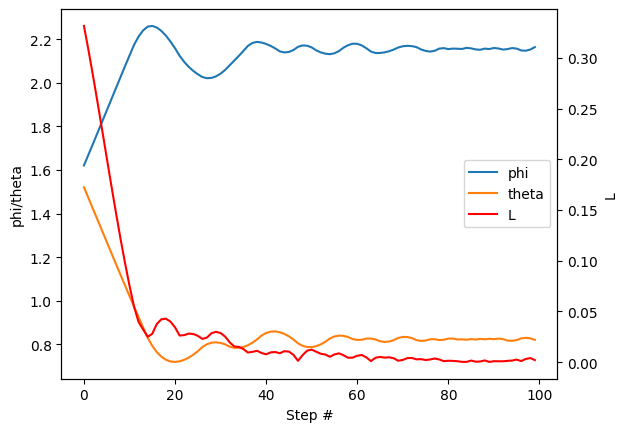

In [8]:
data = np.loadtxt("time-dependent-optimization_torch/log.dat")
fig, ax1 = plt.subplots()
(l1,) = ax1.plot(data[:, 0], data[:, 1], label="phi")
(l2,) = ax1.plot(data[:, 0], data[:, 2], label="theta")
ax1.set_xlabel("Step #")
ax1.set_ylabel("phi/theta")

ax2 = ax1.twinx()
(l3,) = ax2.plot(data[:, 0], data[:, 3], label="L", color="red")
ax2.set_ylabel("L")

lines = [l1, l2, l3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.show()